In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
import matplotlib.patches as mpatches


# PV Production and Forecast Data pipeline.

Data source: 
- EliaOpenData Plateform, Photovoltaic power production estimation and forecast on Belgian grid (Historical) 
- Luxembourg, January 1st 2021- December 31th 2025 - 15 min granularity
- https://opendata.elia.be/explore/dataset/ods032/information/

In [2]:
path = r"./raw/EliaOpenDataBelgium_2021_2025_Cons_Forecast"
region = "Luxembourg"
month = 5
year = 2025
lower_day = 10
upper_day = 20

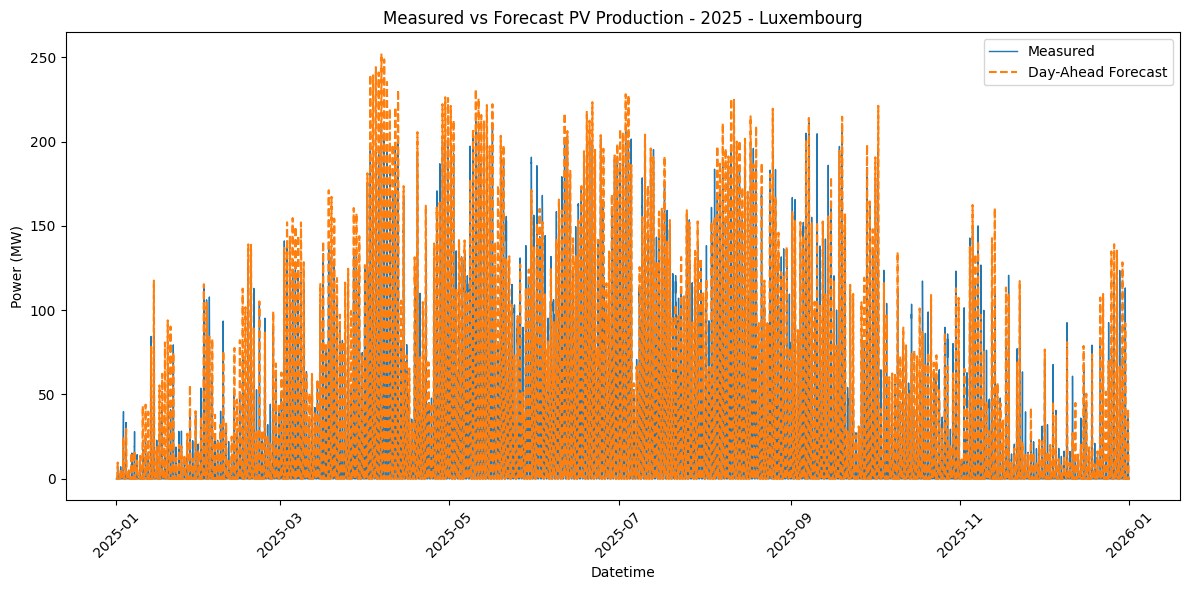

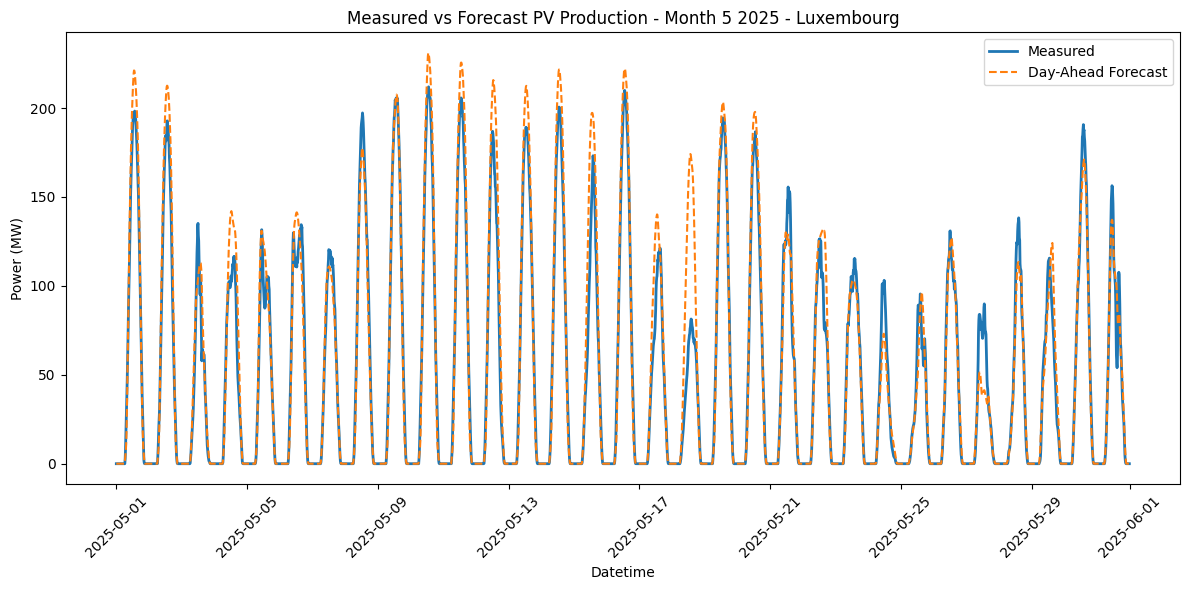

Text(0.5, 1.0, 'Measured vs Forecast PV Production - 10 to 20 of 5  - Luxembourg')

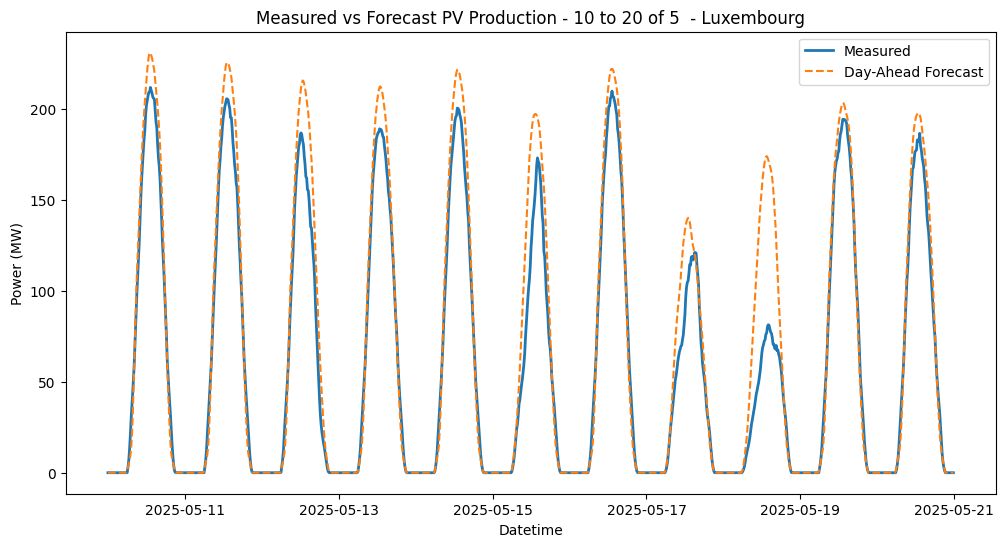

In [3]:

df_region = pd.read_parquet(path + "\production_and_forecast_PV_" + region + "_2021_2025.parquet")

# Ensure datetime is datetime type
df_region["datetime"] = pd.to_datetime(df_region["datetime"])

# Filter year 2021
df_2021 = df_region[df_region["datetime"].dt.year == year]

df_month = df_2021[df_2021["datetime"].dt.month == month]

df_week = df_month[df_month["datetime"].dt.day <= upper_day]
df_week = df_week[df_week["datetime"].dt.day >= lower_day]
# Sort by datetime (important for plotting)
df_2021 = df_2021.sort_values("datetime")

plt.figure(figsize=(12,6))

plt.plot(df_2021["datetime"], df_2021["measured"],
         label="Measured", linewidth=1)

plt.plot(df_2021["datetime"], df_2021["dayaheadforecast"],
         label="Day-Ahead Forecast", linestyle="--")

plt.xlabel("Datetime")
plt.ylabel("Power (MW)")
plt.title(f"Measured vs Forecast PV Production - {year} - {region}")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


plt.figure(figsize=(12,6))
plt.plot(df_month["datetime"], df_month["measured"],
         label="Measured", linewidth=2)
plt.plot(df_month["datetime"], df_month["dayaheadforecast"],
         label="Day-Ahead Forecast", linestyle="--")
plt.xlabel("Datetime")
plt.ylabel("Power (MW)")
plt.title(f"Measured vs Forecast PV Production - Month {month} {year} - {region}")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,6))

plt.plot(df_week["datetime"], df_week["measured"],
         label="Measured", linewidth=2)

plt.plot(df_week["datetime"], df_week["dayaheadforecast"],
         label="Day-Ahead Forecast", linestyle="--")

plt.xlabel("Datetime")
plt.ylabel("Power (MW)")
plt.legend()
plt.title(f"Measured vs Forecast PV Production - {lower_day} to {upper_day} of {month}  - {region}")



C:\Users\egiabica\AppData\Local\Temp\ipykernel_17596\188312133.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot["datetime"] = pd.to_datetime(df_region["datetime"])
C:\Users\egiabica\AppData\Local\Temp\ipykernel_17596\188312133.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot["scaled_measure_irradiance"] = df_plot["measured"]*1e6/(0.22*9.71e5)
C:\Users\egiabica\AppData\Local\Temp\ipykernel_17596\188312133.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice

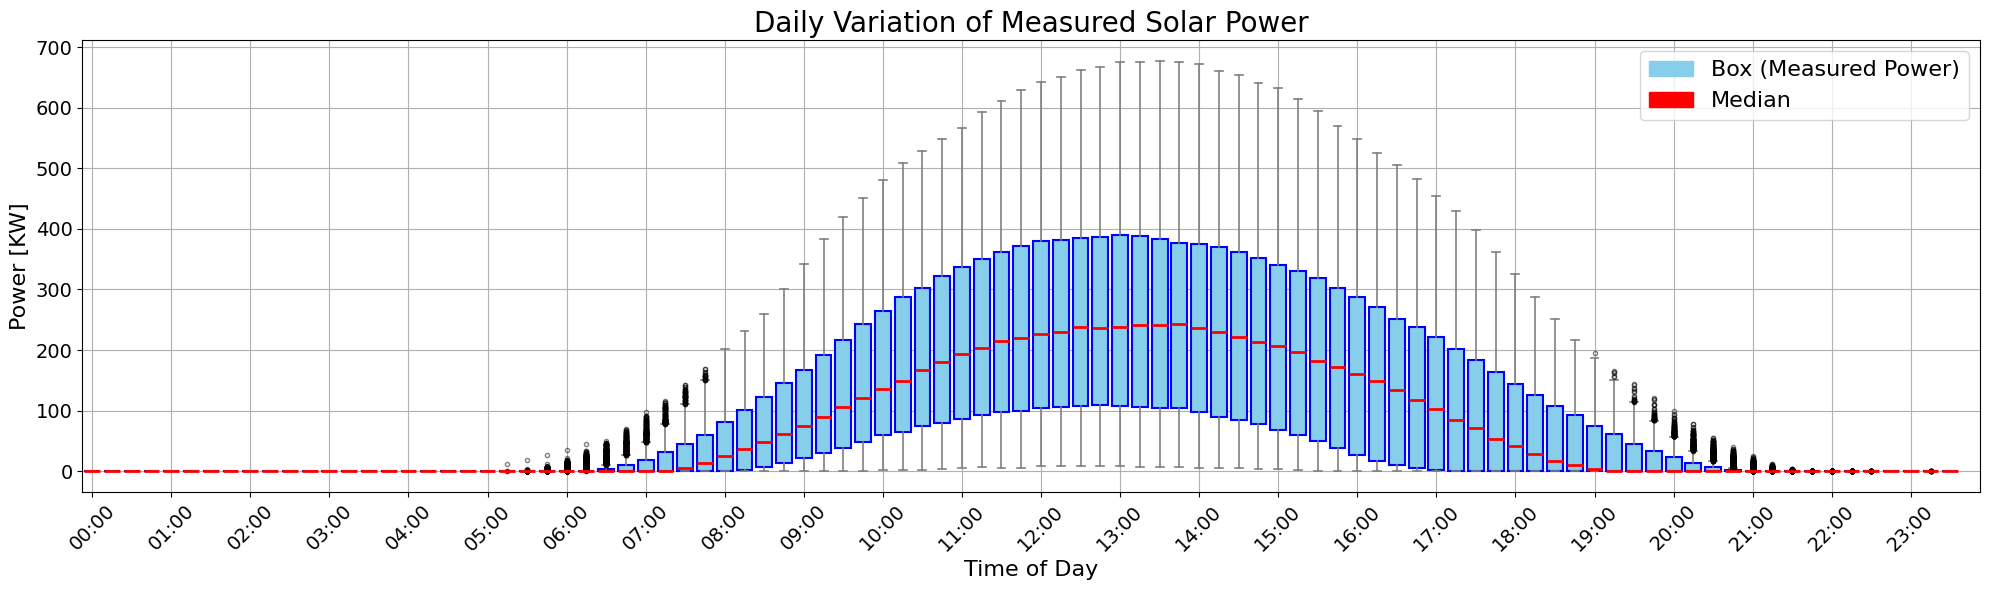

In [4]:

min_value = df_region[df_region["datetime"].dt.year <= 2024]["measured"].min()
max_value = df_region[df_region["datetime"].dt.year <= 2024]["measured"].max()

title_fontsize = 20
label_fontsize = 16
tick_fontsize = 14
legend_fontsize = 16

# -----------------------------
# PREPARE DAILY DATA
# -----------------------------
# Ensure datetime is datetime type

df_plot = df_region[df_region["datetime"].dt.year <= 2024]

df_plot["datetime"] = pd.to_datetime(df_region["datetime"])

estimated_surface = max_value*1e3/0.22

df_plot["scaled_measure_irradiance"] = df_plot["measured"]*1e6/(0.22*9.71e5)

# Compute time step in 15-min intervals (0-95)
df_plot["time_step"] = df_plot["datetime"].dt.hour * 4 + df_plot["datetime"].dt.minute // 15

# Create a list of lists: each element is all "measured" values for that time step across days
daily_data = []
for t in range(96):  # 96 steps per day
    values = df_plot.loc[df_plot["time_step"] == t, "scaled_measure_irradiance"].values
    daily_data.append(values)

# -----------------------------
# PLOT BOX PLOT
# -----------------------------
plt.figure(figsize=(20, 6))

plt.boxplot(
    daily_data,
    positions=np.arange(96),
    widths=0.8,
    patch_artist=True,
    boxprops=dict(facecolor="skyblue", color="blue", linewidth=1.5),
    medianprops=dict(color="red", linewidth=2),
    whiskerprops=dict(color="gray", linewidth=1.2),
    capprops=dict(color="gray", linewidth=1.2),
    flierprops=dict(marker='o', color='gray', markersize=3, alpha=0.5)
)

plt.title("Daily Variation of Measured Solar Power", fontsize=title_fontsize)
plt.xlabel("Time of Day", fontsize=label_fontsize)
plt.ylabel("Power [KW]", fontsize=label_fontsize)

# X-axis ticks every hour
tick_positions = np.arange(0, 96, 4)
tick_labels = [f"{t//4:02d}:00" for t in tick_positions]
plt.xticks(tick_positions, tick_labels, rotation=45, fontsize=tick_fontsize)
plt.yticks(fontsize=tick_fontsize)

plt.grid(True)

# Add legend
box_legend = mpatches.Patch(color="skyblue", label="Box (Measured Power)")
median_legend = mpatches.Patch(color="red", label="Median")
plt.legend(handles=[box_legend, median_legend], fontsize=legend_fontsize)

plt.tight_layout()
plt.show()

# Irradiance Extraction from PV Production

In [9]:
def process_irradiance_forecast(region, path, saving_path, year_max=2025):
    """
    Process PV production data into scaled irradiance and save as parquet.
    
    Parameters
    ----------
    df_region : pd.DataFrame
        Original PV production dataframe. Must contain columns:
        'datetime', 'measured', 'dayahead6pmforecast', 'dayahead11hforecast'
    region : str
        Name of the region (used in output filename)
    path : str
        Folder path to save the processed parquet file
    year_max : int
        Maximum year to include in the dataset (default: 2025)
    
    Returns
    -------
    df_processed : pd.DataFrame
        Processed dataset with scaled irradiance (W/m²)
    """
    df_region = pd.read_parquet(path + "\production_and_forecast_PV_" + region + "_2021_2025.parquet")

    # -----------------------------
    # FILTER YEARS
    # -----------------------------
    df_filtered = df_region[df_region["datetime"].dt.year <= year_max].copy()
    df_filtered["datetime"] = pd.to_datetime(df_filtered["datetime"])
    
    # -----------------------------
    # COMPUTE PEAK POWER
    # -----------------------------
    max_measured_power = df_filtered["measured"].max()  # in MW
    
    # -----------------------------
    # COMPUTE SCALED IRRADIANCE (W/m²)
    # -----------------------------
    efficiency = 0.22
    
    df_filtered["measured_irradiance"] = df_filtered["measured"] * 1e6 / (efficiency * max_measured_power * 1e6)
    df_filtered["dayahead6pmforecast_irradiance"] = df_filtered["dayaheadforecast"] * 1e6 / (efficiency * max_measured_power * 1e6)
    df_filtered["dayahead11amforecast_irradiance"] = df_filtered["dayahead11hforecast"] * 1e6 / (efficiency * max_measured_power * 1e6)
    
    # Scale from fraction → W/m²
    df_filtered["measured_irradiance"] *= 1e6 / 0.22
    df_filtered["dayahead6pmforecast_irradiance"] *= 1e6 / 0.22
    df_filtered["dayahead11amforecast_irradiance"] *= 1e6 / 0.22
    
    # Actually the scaling simplifies to:
    # irradiance [W/m²] = measured [MW] * 1e6 / 0.22 / (max_measured [MW])
    
    df_filtered["measured_irradiance"] = df_filtered["measured"] * 1e6 / (efficiency * max_measured_power)
    df_filtered["dayahead6pmforecast_irradiance"] = df_filtered["dayaheadforecast"] * 1e6 / (efficiency * max_measured_power)
    df_filtered["dayahead11amforecast_irradiance"] = df_filtered["dayahead11hforecast"] * 1e6 / (efficiency * max_measured_power)
    
    # -----------------------------
    # SELECT REQUIRED COLUMNS
    # -----------------------------
    df_processed = df_filtered[[
        "datetime",
        "dayahead6pmforecast_irradiance",
        "dayahead11amforecast_irradiance",
        "measured_irradiance"
    ]].copy()
    
    # -----------------------------
    # SAVE TO PARQUET
    # -----------------------------
    filename = f"processed_irradiance_forecast_production_{region}_2021_2025.parquet"
    output_file = os.path.join(saving_path, filename)
    df_processed.to_parquet(output_file, index=False)
    
    print(f"Processed data saved to: {output_file}")
    
    return df_processed



In [10]:
# -----------------------------
# Example usage
# -----------------------------
path = r"./raw/EliaOpenDataBelgium_2021_2025_Cons_Forecast"
saving_path = r"./processed/Irradiance_2021_2025_Elia_Consumption_Forecast"
region = "Luxembourg"

# df_region is assumed to be already loaded
df_processed = process_irradiance_forecast(region, path, saving_path, 2024)


Processed data saved to: ./processed/Irradiance_2021_2025_Elia_Consumption_Forecast\processed_irradiance_forecast_production_Luxembourg_2021_2025.parquet
